# HydroSense-Kenya: Smart Irrigation System
## Level 1 - Problem Framing and Python Foundation

Student: ELPIS MWANGI MAINA
Student Number: SCT211-0003/2024

## Problem Statement

Kenya's agricultural sector faces critical challenges from water scarcity, climate variability, and inefficient irrigation practices. With approximately 80% of the country classified as arid or semi-arid, water represents the most limiting resource for agricultural productivity. Smallholder farmers and medium-scale agricultural enterprises often depend on traditional irrigation methods that waste significant water quantities through inefficient scheduling practices and lack of real-time soil moisture monitoring. This fundamental challenge undermines both agricultural sustainability and economic viability across rural regions.

A university demonstration farm or agricultural innovation hub seeks to improve water-use efficiency through data-driven decision support. Currently, farmers make irrigation decisions based primarily on experience, intuition, or simplistic fixed schedules (such as "water every three days") rather than objective field data. This approach leads to multiple negative outcomes: overwatering wastes 30-50% of applied water without improving crop yields, underwatering exposes crops to moisture stress that reduces production and quality, unnecessary water consumption increases operational costs for pumping and electricity, and excessive groundwater extraction depletes critical water resources essential for long-term agricultural sustainability.

### Central Research Question

Given daily weather records including rainfall, temperature, humidity, wind speed, and solar radiation, combined with soil-moisture sensor data from multiple farm zones, how can we: (1) develop and validate a soil water balance model that accurately tracks daily moisture changes, (2) estimate water deficit and detect crop moisture stress conditions, (3) simulate future soil moisture evolution under different rainfall scenarios, and (4) recommend irrigation schedules that minimize water consumption while maintaining crop health and preventing yield losses from moisture stress?

### Scientific Approach

This project implements a discrete water-balance model that tracks daily changes in soil moisture at each farm location:

S(t+1) = S_t + R_t + I_t - ET_t - D_t

Where S_t represents soil moisture at time t, R_t is rainfall, I_t is applied irrigation, ET_t is evapotranspiration (crop water loss), and D_t is drainage beyond field capacity. Daily evapotranspiration is estimated using a simplified empirical model: ET = max(0, 0.12T + 0.35W + 2.4Solar - 0.025H), capturing the main weather effects without requiring detailed agronomic data. The model operates on daily time steps, appropriate for irrigation scheduling decisions made by farm managers.

### Significance and Impact

From an environmental perspective, this work directly reduces water waste and protects groundwater resources that are critical for future agricultural sustainability in arid regions. Economically, the approach lowers operational costs through efficient resource scheduling, improving farm profitability and competitiveness. Agriculturally, maintaining crops within optimal moisture ranges maximizes yield per unit water applied, supporting food security. Socially, the system empowers farmers with evidence-based decision support rather than guesswork, building capacity for adaptive management. Educationally, the project demonstrates practical computational methods for agronomy challenges facing developing agricultural systems.

### Project Scope and Constraints

The model encompasses daily water balance calculations using simplified ET and drainage equations, three distinct farm zones cultivating different crops (tomato, kale, and maize), 30-day observation periods containing real environmental variability, and spatial variations in soil properties and crop types across zones. Simplifications include using daily rather than hourly time steps, empirical rather than physics-based ET models, linear drainage representations, exclusion of groundwater interactions, and absence of plant physiological stress feedback mechanisms. These trade-offs balance model complexity against data availability and computational requirements appropriate for educational contexts and resource-limited settings.

## Data Dictionary

### Weather Daily Variables

| Variable | Unit | Type | Range | Description |
|----------|------|------|-------|-------------|
| date | YYYY-MM-DD | datetime | 2026-03-04 to 2026-04-02 | Date of measurement |
| rainfall_mm | mm | float | 0.0 - 85.0 | Daily precipitation |
| temperature_c | C | float | 18.0 - 45.8 | Mean air temperature |
| humidity_pct | % | float | 35.0 - 95.0 | Relative humidity |
| wind_speed_mps | m/s | float | 0.5 - 4.5 | Mean wind speed |
| solar_index | dimensionless | float | 0.2 - 0.95 | Solar radiation index |

### Soil Sensor Data Variables

| Variable | Unit | Type | Range | Description |
|----------|------|------|-------|-------------|
| timestamp | datetime | datetime | 12:00 daily | Measurement time |
| zone_id | categorical | string | Zone_A, Zone_B, Zone_C | Farm zone identifier |
| soil_moisture_pct | % | float | 15.0 - 45.0 | Volumetric soil moisture |
| tank_level_liters | L | float | 3000 - 9900 | Water tank level |
| pump_flow_lpm | L/min | float | 0.0 - 150.0 | Pump flow rate |
| pump_power_watts | W | float | 0.0 - 2500.0 | Electrical power consumed |
| sensor_status | categorical | string | OK, CHECK, ERROR | Sensor operational status |

### Crop Zone Parameters

| Variable | Unit | Type | Range | Description |
|----------|------|------|-------|-------------|
| zone_id | categorical | string | Zone_A, Zone_B, Zone_C | Zone identifier |
| crop_type | categorical | string | Tomato, Kale, Maize | Crop species |
| area_m2 | m2 | float | 1000 - 5000 | Zone area |
| min_moisture_pct | % | float | 20.0 - 24.0 | Stress threshold |
| target_moisture_pct | % | float | 30.0 - 35.0 | Optimal moisture |
| field_capacity_pct | % | float | 40.0 - 45.0 | Maximum storage |
| drainage_coefficient | dimensionless | float | 0.15 - 0.20 | Daily loss fraction |

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
weather = pd.read_csv('../data/raw/weather_daily.csv')
soil = pd.read_csv('../data/raw/soil_sensor_data.csv')
params = pd.read_csv('../data/raw/crop_zone_parameters.csv')

weather['date'] = pd.to_datetime(weather['date'])
soil['timestamp'] = pd.to_datetime(soil['timestamp'])

print("Data loaded successfully")


Data loaded successfully


## Scientific Visualization: Daily Rainfall Time Series

This plot shows daily rainfall over the 30-day observation period, revealing rainfall patterns and variability important for irrigation planning. High variability indicates need for flexible irrigation scheduling.

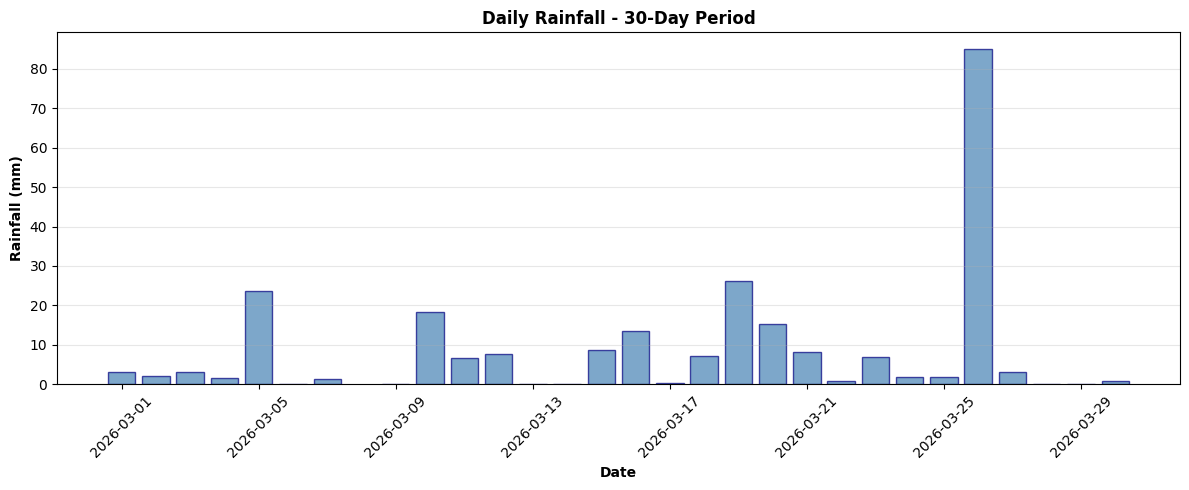

Total rainfall: 247.4 mm
Mean daily rainfall: 8.5 mm
Max daily rainfall: 85.0 mm


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(weather['date'], weather['rainfall_mm'], color='steelblue', alpha=0.7, edgecolor='navy')
ax.set_xlabel('Date', fontweight='bold')
ax.set_ylabel('Rainfall (mm)', fontweight='bold')
ax.set_title('Daily Rainfall - 30-Day Period', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total rainfall: {weather['rainfall_mm'].sum():.1f} mm")
print(f"Mean daily rainfall: {weather['rainfall_mm'].mean():.1f} mm")
print(f"Max daily rainfall: {weather['rainfall_mm'].max():.1f} mm")
